# Practical Session 01a &mdash; Structured (tabular) data

**Companion to Lecture&nbsp;01 (Introduction to Machine Learning).** This is the first of
five practical notebooks for Session&nbsp;01:

| # | Notebook | Topic |
|---|----------|-------|
| **01a** | **structured data** | **tables, the design matrix, feature types, encoding (this notebook)** |
| 01b | unstructured data | images, sound, time series |
| 01c | EDA & cleaning | exploring and fixing messy data |
| 01d | train / val / test | honest evaluation — why a validation set matters |
| 01e | first ML pipeline | an end-to-end, leak-free workflow |

Before a model can learn anything, the data has to become **numbers in an array**. This
notebook is about the most common starting point: **structured** (a.k.a. *tabular*) data &mdash;
the kind that lives in a spreadsheet or a database table.

> ⭐ **Key idea.** In supervised learning a dataset is a pair $(\mathbf{X},\,\mathbf{y})$:
> a **design matrix** $\mathbf{X}\in\mathbb{R}^{n\times d}$ with **one row per example** and
> **one column per feature**, and a **target** vector $\mathbf{y}$ with the answer for each
> row. Everything else in this course is a variation on that shape.

*Run each cell (Shift+Enter). Cells marked `# <-- CHANGE ME` are meant to be edited.*

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nb_utils import use_style      # local styling helper (sibling file)
from nb_data import make_apartments # local synthetic dataset (sibling file)

use_style("notes")
pd.set_option("display.precision", 2)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.1 | numpy 2.2.4


## 1. One row = one example

We will predict the **monthly rent** of an apartment from a few measured attributes &mdash;
exactly the worked example from the lecture slides. Each **row** is one apartment (one
*example*); each **column** is one *attribute* we measured.

In [2]:
df = make_apartments(n=400, seed=0)   # a clean, synthetic table (no download needed)
df.head()

,area_m2,rooms,bathrooms,floor,building_age,neighborhood,has_elevator,dist_center_km,rent_eur
0,78.1,3,1,5,27,Norte,True,1.57,1185.0
1,71.7,3,2,8,73,Norte,True,5.57,1084.0
2,91.0,2,1,11,9,Centro,True,9.95,1271.0
3,77.6,4,2,5,56,Norte,True,0.28,1210.0
4,61.6,1,1,7,64,Sur,True,1.44,343.0


Read that table the way a model does:

* the first row is **one example** &mdash; a 78&nbsp;m&sup2; apartment, 3 rooms, in *Norte*, &hellip;
* every row has the **same columns in the same order** (that regularity is what makes it
  *structured*);
* one special column, `rent_eur`, is the **thing we want to predict** (the *target*); the
  rest are the **inputs** the model is allowed to use.

## 2. The anatomy of a `DataFrame`

A pandas `DataFrame` is the workhorse container for tabular data. Three things describe its
shape and contents: `.shape`, `.columns`, and `.dtypes`.

In [3]:
print("shape (rows, columns):", df.shape)      # (n examples, d columns incl. target)
print("n examples:", df.shape[0])
print("columns:", list(df.columns))
print()
print("dtypes (how each column is stored):")
print(df.dtypes)

shape (rows, columns): (400, 9)
n examples: 400
columns: ['area_m2', 'rooms', 'bathrooms', 'floor', 'building_age', 'neighborhood', 'has_elevator', 'dist_center_km', 'rent_eur']

dtypes (how each column is stored):
area_m2           float64
rooms               int64
bathrooms           int64
floor               int64
building_age        int64
neighborhood       object
has_elevator         bool
dist_center_km    float64
rent_eur          float64
dtype: object


> 🔬 **Going deeper.** `.shape` is `(n, d+1)` here: `n = 400` examples and `d = 8` feature
> columns plus 1 target column. The **dtype** of a column decides what a model can do with
> it: arithmetic makes sense on `float64`/`int64` columns, but not on the `object` (text)
> column `neighborhood` &mdash; that one will need *encoding* (Section&nbsp;5).

`.info()` and `.describe()` give a fast, complete first look &mdash; we lean on them heavily in
notebook&nbsp;01c.

In [4]:
df.describe().round(1)   # count / mean / std / min / quartiles / max for numeric columns

,area_m2,rooms,bathrooms,floor,building_age,dist_center_km,rent_eur
count,400.0,400.0,400.0,400.0,400.0,400.0,400.0
mean,74.4,2.7,1.4,5.6,40.5,3.9,989.1
std,24.0,1.1,0.6,3.6,24.2,2.2,432.7
min,25.0,1.0,1.0,0.0,0.0,0.2,250.0
25%,57.4,2.0,1.0,2.0,21.0,2.3,672.5
50%,73.8,3.0,1.0,6.0,40.0,3.6,993.0
75%,91.0,3.0,2.0,9.0,62.0,5.5,1231.0
max,151.7,6.0,3.0,11.0,79.0,10.3,2427.0


## 3. Not all columns are the same *kind* of number

Telling the feature **types** apart is the first modelling decision, because each type is
handled differently.

In [5]:
schema = pd.DataFrame({
    "column":  ["area_m2","rooms","bathrooms","floor","building_age",
                "neighborhood","has_elevator","dist_center_km","rent_eur"],
    "kind":    ["numeric (continuous)","numeric (count)","numeric (count)",
                "numeric (count/ordinal)","numeric (continuous)","categorical (nominal)",
                "boolean","numeric (continuous)","TARGET (continuous)"],
    "example": [df.area_m2.iloc[0], df.rooms.iloc[0], df.bathrooms.iloc[0], df.floor.iloc[0],
                df.building_age.iloc[0], df.neighborhood.iloc[0], df.has_elevator.iloc[0],
                df.dist_center_km.iloc[0], df.rent_eur.iloc[0]],
})
schema

,column,kind,example
0,area_m2,numeric (continuous),78.1
1,rooms,numeric (count),3
2,bathrooms,numeric (count),1
3,floor,numeric (count/ordinal),5
4,building_age,numeric (continuous),27
5,neighborhood,categorical (nominal),Norte
6,has_elevator,boolean,True
7,dist_center_km,numeric (continuous),1.57
8,rent_eur,TARGET (continuous),1185.0


* **Continuous numeric** (`area_m2`, `dist_center_km`): any real value in a range.
* **Count / discrete** (`rooms`, `bathrooms`, `floor`): whole numbers; often also *ordinal*
  (a natural order, e.g. floor 2 < floor 5).
* **Categorical / nominal** (`neighborhood`): a label from a finite set with **no numeric
  order** &mdash; *Centro* is not "greater than" *Sur*.
* **Boolean** (`has_elevator`): a yes/no flag, trivially encoded as 1/0.

> ⚠️ **Watch out.** A common beginner bug is to feed a *nominal* category to a model as an
> integer code (Centro=0, Norte=1, &hellip;). The model then thinks Norte is "twice" Centro,
> which is meaningless. Nominal categories need **one-hot** encoding (Section&nbsp;5), not an
> integer.

## 4. Splitting into the design matrix $\mathbf{X}$ and the target $\mathbf{y}$

Supervised learning always separates the **inputs** (features) from the **output** (target).
By convention the features go into a matrix $\mathbf{X}$ and the target into a vector
$\mathbf{y}$.

In [6]:
target = "rent_eur"
X = df.drop(columns=[target])   # the 8 feature columns
y = df[target]                  # the single target column

print("X shape:", X.shape, "  <- (n examples, d features)")
print("y shape:", y.shape, "  <- one target per example")
print("\nOne example x_i (row 0) as a feature vector:")
print(X.iloc[0])

X shape: (400, 8)   <- (n examples, d features)
y shape: (400,)   <- one target per example

One example x_i (row 0) as a feature vector:
area_m2            78.1
rooms                 3
bathrooms             1
floor                 5
building_age         27
neighborhood      Norte
has_elevator       True
dist_center_km     1.57
Name: 0, dtype: object


> 🔬 **Going deeper.** Row $i$ of $\mathbf{X}$ is the **feature vector**
> $\mathbf{x}_i=(x_{i1},\dots,x_{id})$ for example $i$, and $y_i$ is its target. A supervised
> model is a function $h_\theta:\mathbf{x}\mapsto\hat y$ with parameters $\theta$ that we fit
> so that $\hat y_i \approx y_i$ across the rows. Keeping $\mathbf{X}$ and $\mathbf{y}$
> strictly separate is what stops us from *accidentally* letting the answer leak into the
> inputs (a classic mistake &mdash; more in 01c and 01e).

## 5. Making everything numeric: encoding categories

Most models can only do arithmetic, so the text column `neighborhood` and the boolean
`has_elevator` must become numbers. The safe, general tool for a **nominal** category is
**one-hot encoding**: one new 0/1 column per category.

In [ ]:
# one-hot encode the nominal category; booleans map to 0/1 automatically
X_numeric = pd.get_dummies(X, columns=["neighborhood"], dtype=int)
X_numeric["has_elevator"] = X_numeric["has_elevator"].astype(int)

print("before encoding:", X.shape, " -> after one-hot:", X_numeric.shape)
print("new columns:", [c for c in X_numeric.columns if c.startswith("neighborhood_")])
X_numeric.head(3)

before encoding: (400, 8)  -> after one-hot: (400, 12)
new columns: ['neighborhood_Centro', 'neighborhood_Este', 'neighborhood_Norte', 'neighborhood_Oeste', 'neighborhood_Sur']


,area_m2,rooms,bathrooms,floor,building_age,has_elevator,dist_center_km,neighborhood_Centro,neighborhood_Este,neighborhood_Norte,neighborhood_Oeste,neighborhood_Sur
0,78.1,3,1,5,27,1,1.57,0,0,1,0,0
1,71.7,3,2,8,73,1,5.57,0,0,1,0,0
2,91.0,2,1,11,9,1,9.95,1,0,0,0,0


Notice what happened: the single `neighborhood` column became **five** `neighborhood_*`
columns, each 0/1. The design matrix went from 8 to 12 columns. Now every entry is a number,
so $\mathbf{X}$ is a genuine matrix a model can multiply.

> 🔬 **Going deeper.** Encoding choices:
> * **One-hot** &mdash; for nominal categories; no false ordering, but adds columns.
> * **Ordinal** &mdash; map an *ordered* category to `0,1,2,&hellip;` (e.g. `low<med<high`). Only
>   valid when the order is real.
> * **Label encoding** (an integer per class) is fine for the **target** of a *classifier*,
>   but **not** for nominal *inputs* (it invents an order).
>
> In 01e we do this the production way &mdash; inside a `ColumnTransformer` &mdash; so the encoding is
> learned on the training split only and never leaks.

## 6. The columns live on very different scales

Look at the ranges: `area_m2` spans tens to hundreds, `rooms` is 1&ndash;6, `dist_center_km`
is single digits. Many models (anything using distances or gradients &mdash; k-NN, SVMs, linear
models with regularization, neural nets) are **sensitive to scale**: a feature with big
numbers can dominate purely because of its units.

In [8]:
ranges = X_numeric.agg(["min", "max", "mean", "std"]).T
ranges["span"] = ranges["max"] - ranges["min"]
ranges.sort_values("span", ascending=False).round(2).head(6)

,min,max,mean,std,span
area_m2,25.0,151.70,74.43,24.05,126.70
building_age,0.0,79.00,40.47,24.21,79.00
floor,0.0,11.00,5.59,3.62,11.00
dist_center_km,0.2,10.31,3.95,2.23,10.11
rooms,1.0,6.00,2.68,1.12,5.00
bathrooms,1.0,3.00,1.42,0.58,2.00


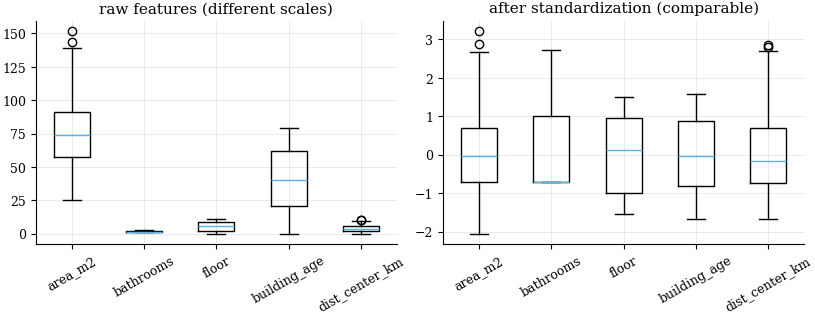

In [9]:
# Standardization: subtract the mean, divide by the std -> mean 0, std 1 (same shape, comparable columns)
num_cols = ["area_m2", "bathrooms", "floor", "building_age", "dist_center_km"]
standardized = (X_numeric[num_cols] - X_numeric[num_cols].mean()) / X_numeric[num_cols].std()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.2, 3.2))
X_numeric[num_cols].boxplot(ax=a1, rot=30); a1.set_title("raw features (different scales)")
standardized.boxplot(ax=a2, rot=30); a2.set_title("after standardization (comparable)")
for a in (a1, a2): a.grid(alpha=0.3)
plt.show()

> ⚠️ **Watch out.** Standardization uses the mean and std of the data. Those statistics must
> be computed on the **training set only** and then applied to validation/test &mdash; otherwise
> information about the test set leaks into training. Doing it by hand on the whole table (as
> above, just for illustration) is exactly the mistake 01e shows how to avoid with a
> `Pipeline`.

## 7. From `DataFrame` to a raw NumPy array

Under the hood, scikit-learn models consume a plain float array. `.to_numpy()` is the bridge
from the labelled `DataFrame` to that array.

In [10]:
X_array = X_numeric.to_numpy(dtype=float)
y_array = y.to_numpy(dtype=float)

print("X_array:", type(X_array).__name__, X_array.shape, X_array.dtype)
print("y_array:", type(y_array).__name__, y_array.shape, y_array.dtype)
print("\nThis 400x12 float matrix is what a model actually sees:")
print(np.round(X_array[:3], 2))

X_array: ndarray (400, 12) float64
y_array: ndarray (400,) float64

This 400x12 float matrix is what a model actually sees:
[[78.1   3.    1.    5.   27.    1.    1.57  0.    0.    1.    0.    0.  ]
 [71.7   3.    2.    8.   73.    1.    5.57  0.    0.    1.    0.    0.  ]
 [91.    2.    1.   11.    9.    1.    9.95  1.    0.    0.    0.    0.  ]]


A quick look at how one feature relates to the target &mdash; the kind of signal a model exploits.
(Systematic exploration is the whole of notebook&nbsp;01c.)

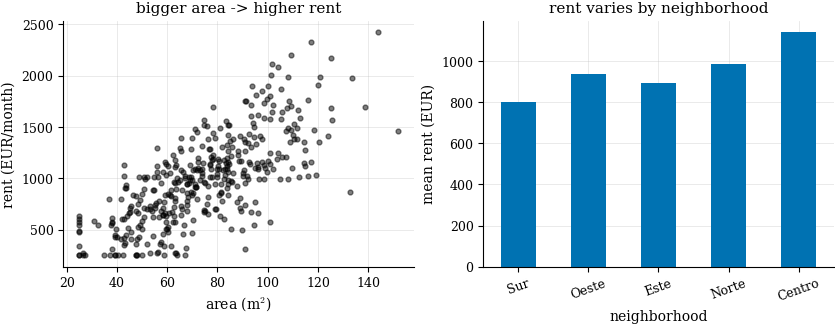

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.4, 3.3))
a1.scatter(df.area_m2, df.rent_eur, s=12, alpha=0.5)
a1.set_xlabel("area (m$^2$)"); a1.set_ylabel("rent (EUR/month)")
a1.set_title("bigger area -> higher rent")
order = ["Sur", "Oeste", "Este", "Norte", "Centro"]
df.groupby("neighborhood")["rent_eur"].mean().reindex(order).plot.bar(ax=a2, color="#0072B2")
a2.set_ylabel("mean rent (EUR)"); a2.set_title("rent varies by neighborhood"); a2.tick_params(axis="x", rotation=20)
plt.show()

## 8. The same shape, on a real dataset (optional)

Our apartments table is synthetic so the notebook runs offline. The **shape of the problem**
is identical on real data. Here is a real, bundled scikit-learn dataset &mdash; diabetes disease
progression &mdash; already in the `(\mathbf{X}, \mathbf{y})` form.

In [12]:
from sklearn.datasets import load_diabetes

real = load_diabetes(as_frame=True)
print("features:", real.data.shape, "| target:", real.target.shape)
print("feature names:", list(real.data.columns))
real.frame.head(3)

features: (442, 10) | target: (442,)
feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,3.81e-02,0.05,0.06,2.19e-02,-4.42e-02,-0.03,-0.04,-2.59e-03,1.99e-02,-0.02,151.0
1,-1.88e-03,-0.04,-0.05,-2.63e-02,-8.45e-03,-0.02,0.07,-3.95e-02,-6.83e-02,-0.09,75.0
2,8.53e-02,0.05,0.04,-5.67e-03,-4.56e-02,-0.03,-0.03,-2.59e-03,2.86e-03,-0.03,141.0


> 💡 **Tip (real downloadable data).** To pull a larger real table over the network, scikit-learn
> offers `fetch_openml`, e.g. `fetch_openml("titanic", version=1, as_frame=True)` (needs
> internet, and we clean that exact dataset in 01c). The lesson is unchanged: every supervised
> tabular problem is a design matrix $\mathbf{X}$ and a target $\mathbf{y}$.

## Recap & exercises

**Recap.**
* Structured data = a table: **one row per example, one column per feature**.
* Supervised learning splits it into a design matrix $\mathbf{X}\in\mathbb{R}^{n\times d}$
  and a target $\mathbf{y}$.
* Feature **types** (continuous / count / nominal / boolean) are handled differently;
  nominal categories need **one-hot** encoding, never a fake integer order.
* Columns live on different **scales**; standardization makes them comparable &mdash; but the
  statistics must come from the **training set only** (leakage!).
* Models ultimately consume a plain **NumPy float array** (`.to_numpy()`).

**Exercises.**
1. Change `make_apartments(n=..., seed=...)`: how do `df.shape` and `df.describe()` change?
2. One-hot encode with `pd.get_dummies(..., drop_first=True)`. How many columns now, and why
   might you drop one? (Hint: multicollinearity / the "dummy variable trap".)
3. Add a new engineered feature `rent_per_m2 = rent_eur / area_m2` to `df`. Is it a feature or
   a form of the target? Why would including it as a feature be *leakage*?
4. Pick two numeric columns and standardize them by hand; verify the result has mean ≈ 0 and
   std ≈ 1 with `.mean()` / `.std()`.
5. Load `load_wine(as_frame=True)` and identify $n$, $d$, the target, and each feature's type.

*Next:* **01b &mdash; unstructured data** (images, sound, time series): when one example is *not* a
table row.